# ***ASSIGNMENT 4: Training a DCGAN on the Fashion-MNIST Dataset***

###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 12-09-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

## **Objective**

####The objective of this assignment is to understand the working and training process of a Deep Convolutional Generative Adversarial Network (DCGAN).

####In this experiment, a DCGAN is implemented using the Fashion-MNIST dataset. The model contains two important neural networks: a Generator and a Discriminator.

####The Generator learns to create new images that look similar to the real Fashion-MNIST images. The Discriminator learns to distinguish between real images from the dataset and fake images generated by the Generator.

####Both networks are trained together in a competitive learning process. As training progresses, the Generator attempts to produce more realistic images, while the Discriminator becomes better at identifying fake images.

####The generated images are observed at different stages of training to understand how their quality changes over time.

# **1. Introduction**

####Generative Adversarial Networks, commonly known as GANs, are a type of deep learning model used to generate new data that resembles an existing dataset.

####A GAN consists of two neural networks called the Generator and the Discriminator. These two networks have different responsibilities, but they work together during the training process.

####The Generator is responsible for creating synthetic or fake data. In this assignment, the Generator takes a random noise vector as input and produces a grayscale image of size 28 × 28 pixels.

####The Discriminator is responsible for deciding whether an input image is real or fake. A real image comes from the Fashion-MNIST dataset, while a fake image is produced by the Generator.

####The Generator and Discriminator compete with each other during training. The Generator tries to fool the Discriminator by creating realistic images, while the Discriminator tries to correctly identify the generated images as fake.

####A Deep Convolutional Generative Adversarial Network, or DCGAN, improves the basic GAN architecture by using convolutional layers in the Discriminator and transposed convolutional layers in the Generator.

####Convolutional layers are useful for extracting important visual features such as edges, shapes and patterns from images. Transposed convolutional layers help the Generator gradually increase the spatial size of its feature maps and create an image.

####In this assignment, the Fashion-MNIST dataset is used to train a DCGAN. The model is trained for 30 epochs, and generated images are saved every 5 epochs. The Generator and Discriminator losses are also recorded and plotted to study the behavior of the model during training.

# **2. What is a DCGAN?**

####DCGAN stands for Deep Convolutional Generative Adversarial Network.

####It is an extension of the traditional Generative Adversarial Network that uses convolutional neural network operations for image generation and classification.

####A DCGAN contains two main components:

### 1. Generator

####The Generator receives a random noise vector as input. It processes this random vector through several layers and converts it into an image.

####In this experiment, the Generator uses Dense and transposed convolutional layers. The spatial size of the feature maps gradually increases from a smaller representation to a 28 × 28 image.

####The final layer uses the tanh activation function. Therefore, the generated image values are in the range of -1 to +1.

### 2. Discriminator

####The Discriminator receives an image as input and determines whether the image is real or fake.

####It uses convolutional layers to extract features from the image. These features are passed through additional layers to produce a final probability.

####The final sigmoid activation produces a value between 0 and 1.

####A value close to 1 indicates that the Discriminator considers the image real, while a value close to 0 indicates that it considers the image fake.

### Competitive Training

####The Generator and Discriminator are trained together.

####The Generator tries to improve its ability to create realistic images, while the Discriminator tries to improve its ability to distinguish real images from fake images.

####This competitive process continues for multiple epochs. As training progresses, the Generator should gradually learn the patterns and structures present in the Fashion-MNIST dataset.

# **3. About the Fashion-MNIST Dataset**

####Fashion-MNIST is a popular image dataset commonly used for machine learning and deep learning experiments.

####It contains grayscale images representing different categories of clothing and fashion-related objects.

####Each image has a resolution of 28 × 28 pixels. Since the images are grayscale, each pixel contains a single intensity value.

####The dataset contains:

- 60,000 training images
- 10,000 test images
- 28 × 28 pixel image resolution
- One grayscale channel
- 10 different fashion categories

####The ten categories represented in Fashion-MNIST are:

1. T-shirt / Top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle Boot

####For this assignment, the training images are used to train the DCGAN.

####The labels are not directly required for GAN image generation because the model is learning the overall visual distribution of the images rather than performing classification.

####The objective is to make the Generator learn the visual patterns present in the Fashion-MNIST dataset and create new images that resemble the original clothing images.

# **4. Importing the Required Libraries**

####Several Python libraries are required to implement and train the DCGAN.

####TensorFlow and Keras are used to create the deep learning models and perform the training process.

####NumPy is used for numerical operations and processing the dataset.

####Matplotlib is used to display the original images, generated images and loss graphs.

####The time library is used to calculate the approximate training time for each epoch.

####The operating system library can be used for handling generated files and model files.

####These libraries provide the necessary tools for loading the dataset, building the neural networks, training the models and visualizing the results.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# **5. Checking GPU Availability**

####Training a deep learning model such as a DCGAN can require significant computational resources.

####Google Colab provides access to GPU hardware, which can make the training process faster than using only the CPU.

####A GPU is particularly useful because the DCGAN performs many matrix operations and convolutional operations during training.

####The available GPU devices are checked before beginning the training process.

####If a GPU is available, TensorFlow can automatically use it for suitable operations.

####In Google Colab, GPU acceleration can be enabled through:

####Runtime → Change runtime type → Hardware accelerator → T4 GPU

####The GPU availability is checked using TensorFlow.

In [2]:
print("Available GPUs:")
print(tf.config.list_physical_devices('GPU'))

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **6. Setting the Basic Parameters**

####Before training the DCGAN, several important parameters are defined.

####The batch size determines how many images are processed during one training step. A batch size of 256 is used in this experiment.

####The model is trained for 30 epochs. One epoch represents one complete pass through the training dataset.

####The noise dimension is set to 100. This means that the Generator receives a random vector containing 100 numerical values as its input.

####The Fashion-MNIST images have a resolution of 28 × 28 pixels and contain one grayscale channel.

####A learning rate of 0.0002 is used for both the Generator and Discriminator optimizers.

####The parameters are kept fixed during the experiment so that the generated images can be compared consistently across different epochs.

In [3]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

EPOCHS = 30

NOISE_DIM = 100

IMG_HEIGHT = 28
IMG_WIDTH = 28
CHANNELS = 1

LEARNING_RATE = 0.0002

print("Batch size:", BATCH_SIZE)
print("Number of epochs:", EPOCHS)
print("Noise dimension:", NOISE_DIM)
print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Learning rate:", LEARNING_RATE)

Batch size: 256
Number of epochs: 30
Noise dimension: 100
Image size: 28 x 28
Learning rate: 0.0002


# **7. Loading the Fashion-MNIST Dataset**

####The Fashion-MNIST dataset is loaded using the built-in dataset functionality provided by TensorFlow.

####The dataset is divided into training and testing portions.

####For this experiment, the training images are used for training the DCGAN.

####The labels are loaded as well, although the labels are not required for the GAN training because the DCGAN is learning the image distribution rather than performing supervised classification.

####The training dataset contains 60,000 images, while the testing dataset contains 10,000 images.

####Each image is represented as a 28 × 28 grayscale image.

In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


# **8. Normalizing the Dataset**

####The original pixel values in the Fashion-MNIST dataset range from 0 to 255.

####Deep learning models generally perform better when input values are scaled to a smaller and consistent range.

####In this experiment, the pixel values are normalized to the range -1 to +1.

####The normalization is performed using the following formula:

####Normalized Value = (Pixel Value - 127.5) / 127.5

####Therefore:

- Pixel value 0 becomes -1
- Pixel value 127.5 becomes approximately 0
- Pixel value 255 becomes +1

####This normalization is particularly important because the final layer of the Generator uses the tanh activation function.

####The tanh activation function produces output values between -1 and +1. Therefore, normalizing the real images to the same range allows the real and generated images to have compatible value ranges during GAN training.

In [5]:
X_train = X_train.astype("float32")

X_train = (X_train - 127.5) / 127.5

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: -1.0
Maximum pixel value: 1.0


# **9. Reshaping the Images**

####The original Fashion-MNIST images have the shape 28 × 28.

####Since the DCGAN uses convolutional layers, the images need to include a channel dimension.

####Because Fashion-MNIST is a grayscale dataset, every image contains only one channel.

####Therefore, the image shape is changed from:

####28 × 28

####to:

####28 × 28 × 1

####The value 1 represents the grayscale channel.

####This format is required by the convolutional layers used in the Discriminator.

In [6]:
X_train = X_train.reshape(
    X_train.shape[0],
    IMG_HEIGHT,
    IMG_WIDTH,
    CHANNELS
)

print("Reshaped training data:", X_train.shape)

Reshaped training data: (60000, 28, 28, 1)


# **10. Preparing the Training Dataset**

####After normalization and reshaping, the training images are converted into a TensorFlow Dataset.

####The dataset is shuffled so that the model does not receive the training images in the same order during every training cycle.

####The images are divided into batches using the selected batch size.

####Batch processing improves computational efficiency and allows the model to update its weights after processing groups of images.

####Prefetching is also used so that TensorFlow can prepare the next batch while the current batch is being processed.

####The prepared dataset is now ready to be provided to the DCGAN training loop.

In [7]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training dataset prepared successfully.")

Training dataset prepared successfully.


# **11. Displaying Original Fashion-MNIST Images**

####Before training the DCGAN, a group of original Fashion-MNIST images is displayed.

####These images provide a visual reference for the actual data distribution.

####The images include different types of fashion objects such as footwear, clothing and bags.

####The original images will later be compared with the images generated by the Generator.

####Displaying the original images is useful because it helps us understand what the Generator is expected to learn.

####Since the images were normalized to the range -1 to +1, they are converted back to the range 0 to 1 for visualization.

####The conversion used for displaying the images is:

####Displayed Image = (Normalized Image + 1) / 2

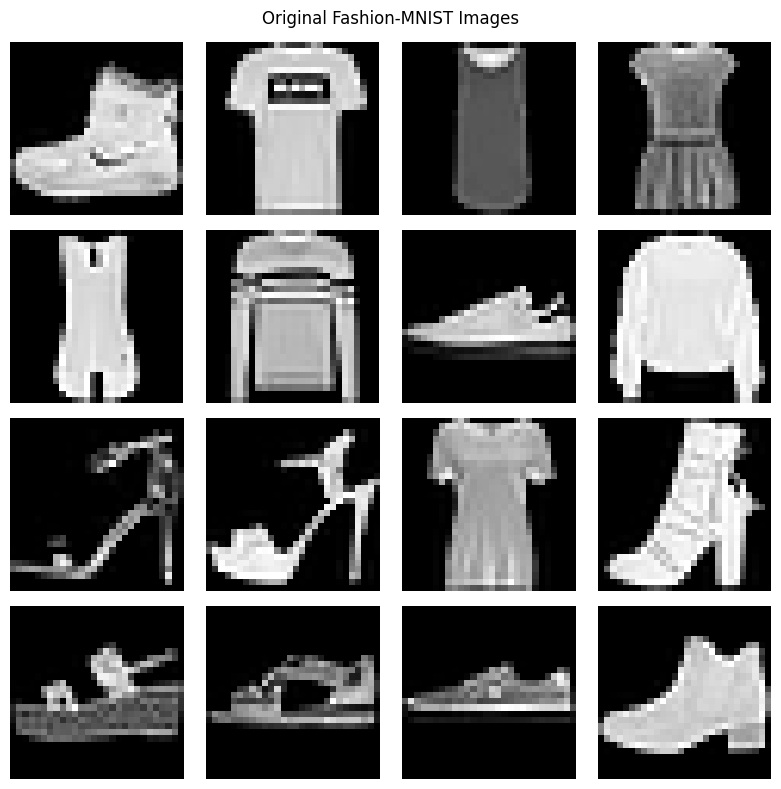

In [8]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(
        (X_train[i] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.tight_layout()
plt.show()

# **12. Building the Generator**

####The Generator is one of the two main components of the DCGAN.

####Its main purpose is to create new images that resemble the images in the Fashion-MNIST dataset.

####The Generator starts with a random noise vector of size 100.

####This noise vector does not contain any meaningful image information. Instead, it acts as the starting point from which the Generator learns to construct an image.

####The first Dense layer transforms the 100-dimensional noise vector into a larger representation.

####The resulting values are reshaped into a 7 × 7 × 256 feature map.

####Transposed convolutional layers are then used to increase the spatial resolution.

####The first transposed convolution increases the feature map from 7 × 7 to 14 × 14.

####The second transposed convolution increases it from 14 × 14 to 28 × 28.

####Finally, another transposed convolutional layer produces a 28 × 28 grayscale image.

####Batch Normalization is used to help stabilize the learning process.

####LeakyReLU activation is used in the intermediate layers.

####The final layer uses the tanh activation function so that the generated pixel values remain between -1 and +1.

####Therefore, the Generator transforms:

####Random Noise → Feature Representation → Larger Feature Maps → Generated Image

In [9]:
def build_generator():

    model = tf.keras.Sequential(name="Generator")

    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Reshape((7, 7, 256))
    )

    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            CHANNELS,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="same",
            activation="tanh"
        )
    )

    return model

# **13. Generator Model Summary**

####The Generator model is created using the architecture defined above.

####The model summary displays each layer, its output shape and the number of trainable parameters.

####The Generator begins with a random noise vector and progressively transforms this vector into an image.

####The use of transposed convolutional layers allows the model to increase the spatial dimensions of the feature maps.

####The final output of the Generator has the shape:

####28 × 28 × 1

####which matches the size and channel structure of the Fashion-MNIST images.

In [10]:
generator = build_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

# **14. Testing the Generator Before Training**

####Before training begins, the Generator is tested using a randomly generated noise vector.

####The noise vector has 100 values and acts as the input to the Generator.

####Since the Generator has not been trained yet, its weights are initialized randomly.

####Therefore, the generated image is not expected to look like a meaningful fashion item at this stage.

####The output will normally appear as random noise or an unclear pattern.

####This initial generated image is useful as a baseline.

####After training, we will compare the generated images with this initial result to understand how much the Generator has learned.

In [11]:
noise = tf.random.normal([1, NOISE_DIM])

generated_image = generator(
    noise,
    training=False
)

print("Noise shape:", noise.shape)
print("Generated image shape:", generated_image.shape)

Noise shape: (1, 100)
Generated image shape: (1, 28, 28, 1)


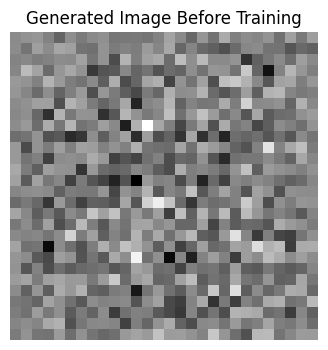

In [12]:
plt.figure(figsize=(4, 4))

plt.imshow(
    (generated_image[0, :, :, 0] + 1) / 2,
    cmap="gray"
)

plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()

# **15. Building the Discriminator**

####The Discriminator is the second major component of the DCGAN.

####Its purpose is to distinguish between real images and fake images.

####Real images are obtained directly from the Fashion-MNIST training dataset.

####Fake images are produced by the Generator.

####The Discriminator receives an image as input and processes it using convolutional layers.

####The convolutional layers extract important visual features from the image.

####The first convolutional layer identifies basic patterns such as edges and simple shapes.

####The following convolutional layer learns more complex visual patterns from the features extracted by the earlier layer.

####Dropout is used to reduce overfitting and improve the robustness of the Discriminator.

####After the convolutional layers, the feature maps are flattened and passed to a Dense output layer.

####The final Dense layer uses the sigmoid activation function.

####The sigmoid function produces a probability between 0 and 1.

####For this experiment:

####Real image → Target value 1

####Fake image → Target value 0

####Therefore, the Discriminator learns to classify the images into two categories: real and fake.

In [13]:
def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    model.add(
        layers.Conv2D(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model

# **16. Discriminator Model Summary**

####The Discriminator is created using convolutional layers.

####The model takes a 28 × 28 × 1 image as input.

####The convolutional layers extract visual features from the image and reduce the spatial dimensions while increasing the number of learned features.

####The extracted features are flattened and passed to the final Dense layer.

####The sigmoid activation function produces a single probability.

####A value closer to 1 indicates that the Discriminator believes the image is real.

####A value closer to 0 indicates that the Discriminator believes the image is fake.

####The Discriminator is therefore trained to become better at separating real Fashion-MNIST images from images generated by the Generator.

In [14]:
discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# **17. Testing the Discriminator Before Training**

####The Discriminator is tested using an image generated by the untrained Generator.

####At this stage, the Discriminator has also not been trained.

####Therefore, its prediction should not be considered accurate.

####The output is a probability between 0 and 1 because the final layer uses the sigmoid activation function.

####During training, the Discriminator will learn to give values close to 1 for real images and values close to 0 for fake images.

####At the same time, the Generator will learn to produce images that cause the Discriminator to give higher real probabilities to generated images.

In [15]:
decision = discriminator(
    generated_image,
    training=False
)

print("Discriminator output:", decision.numpy())

Discriminator output: [[0.49959263]]


# **18. Loss Function**

####Loss functions are used to measure how well the Generator and Discriminator are performing.

####Binary Cross Entropy is used in this DCGAN because the Discriminator performs a binary classification task.

####The Discriminator has two possible classes:

1. Real
2. Fake

####For real images, the target value is 1.

####For fake images, the target value is 0.

####The Generator has a different objective.

####The Generator wants the Discriminator to believe that its generated images are real.

####Therefore, when calculating Generator loss, the generated images are assigned a target value of 1.

####This creates the competitive relationship between the two networks.

####The Discriminator attempts to correctly classify real and fake images, while the Generator attempts to fool the Discriminator.

In [16]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)

# **19. Generator Loss**

####The Generator loss measures how successfully the Generator is able to fool the Discriminator.

####The Generator produces fake images and passes them to the Discriminator.

####The Generator wants the Discriminator to classify these generated images as real.

####Therefore, the target value used for the Generator loss is 1.

####If the Discriminator confidently identifies generated images as fake, the Generator receives a higher loss.

####If the Generator creates images that the Discriminator considers real, the Generator loss can decrease.

####The Generator therefore uses the feedback from the Discriminator to improve the quality of its generated images.

In [17]:
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

# **20. Discriminator Loss**

####The Discriminator loss measures how well the Discriminator can distinguish between real and fake images.

####The Discriminator receives two types of input:

### Real Images

####Real Fashion-MNIST images should be classified as real.

####Target:

1

### Fake Images

####Images generated by the Generator should be classified as fake.

####Target:

0

####The total Discriminator loss is calculated by combining the loss from real images and the loss from fake images.

####A good Discriminator should correctly identify both types of images.

####However, during GAN training, the Generator continuously improves and produces more realistic images. Therefore, the Discriminator also needs to continuously adapt.

In [18]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

# **21. Optimizers**

####An optimizer is used to update the trainable parameters of a neural network based on the calculated gradients.

####The Adam optimizer is used for both the Generator and Discriminator.

####Adam is commonly used in deep learning because it combines ideas from momentum-based optimization and adaptive learning rates.

####A learning rate of 0.0002 is used in this experiment.

####The beta_1 parameter is set to 0.5, which is commonly used in DCGAN implementations to help stabilize the training process.

####The Generator and Discriminator have separate optimizers because they contain different trainable parameters and are updated using their respective losses.

In [19]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.5
)

# **22. Creating a Fixed Noise Vector**

####A fixed set of random noise vectors is created before training.

####Sixteen noise vectors are used because the assignment requires a 4 × 4 grid of generated images.

####A 4 × 4 grid contains:

####4 × 4 = 16 images

####The same noise vectors are used at every selected epoch.

####This is important because it allows us to compare the progress of the Generator fairly.

####For example, if we generate images at Epoch 5 and Epoch 30 using completely different noise vectors, it would be difficult to determine whether the improvement came from training or simply from using different random inputs.

####By using the same noise vectors, we can observe how the Generator changes its output as its learned weights improve.

In [20]:
seed = tf.random.normal(
    [16, NOISE_DIM]
)

print("Fixed noise shape:", seed.shape)

Fixed noise shape: (16, 100)


# **23. DCGAN Training Process**

####The DCGAN training process involves repeatedly updating both the Generator and Discriminator.

####For every training batch, the following steps are performed:

### Step 1: Generate Random Noise

####A random noise vector is created and provided as input to the Generator.

### Step 2: Generate Fake Images

####The Generator converts the random noise into synthetic images.

### Step 3: Classify Real Images

####The Discriminator receives real Fashion-MNIST images and predicts whether they are real.

### Step 4: Classify Fake Images

####The generated images are also given to the Discriminator.

####The Discriminator predicts whether these images are real or fake.

### Step 5: Calculate Generator Loss

####The Generator loss measures how successfully the Generator is able to fool the Discriminator.

### Step 6: Calculate Discriminator Loss

####The Discriminator loss measures how correctly it classifies real and fake images.

### Step 7: Calculate Gradients

####Gradients are calculated for both networks using their respective losses.

### Step 8: Update Weights

####The Adam optimizers update the weights of the Generator and Discriminator.

####This process is repeated for every batch in every epoch.

####As training progresses, both networks continuously adapt to each other.

In [21]:
@tf.function
def train_step(images):

    current_batch_size = tf.shape(images)[0]

    noise = tf.random.normal(
        [current_batch_size, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

# **24. Generating and Saving Images During Training**

####The assignment requires a 4 × 4 grid of generated images to be saved every 5 epochs.

####A function is created for this purpose.

####The function uses the fixed noise vectors created earlier.

####The Generator processes these noise vectors and produces 16 images.

####The images are arranged in a 4 × 4 grid.

####The generated image values are converted from the -1 to +1 range back to the 0 to 1 range for visualization.

####The resulting image grid is displayed and saved as a PNG file.

####The saved images allow us to compare the Generator's performance at different stages of training.

In [22]:
def generate_and_save_images(model, epoch):

    predictions = model(
        seed,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i, :, :, 0] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = f"generated_epoch_{epoch}.png"

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return filename

# **25. Training the DCGAN for 30 Epochs**

####The DCGAN is now trained using the Fashion-MNIST training dataset.

####The model is trained for 30 epochs, satisfying the requirement that the model should be trained for at least 25–30 epochs.

####During every epoch, all batches in the training dataset are processed.

####The Generator loss and Discriminator loss are calculated for every batch.

####The average loss for each epoch is stored for later visualization.

####A 4 × 4 grid of generated images is produced and saved after every 5 epochs.

####Therefore, generated images will be saved at:

- Epoch 5
- Epoch 10
- Epoch 15
- Epoch 20
- Epoch 25
- Epoch 30

####The same fixed noise vectors are used for all these generated image grids.

####This allows the improvement of the Generator to be observed over time.

Starting DCGAN training...

Epoch 01/30 | Generator Loss: 0.7268 | Discriminator Loss: 1.3511 | Time: 28.61s
Epoch 02/30 | Generator Loss: 0.6661 | Discriminator Loss: 1.3990 | Time: 20.91s
Epoch 03/30 | Generator Loss: 0.6938 | Discriminator Loss: 1.3809 | Time: 21.65s
Epoch 04/30 | Generator Loss: 0.7076 | Discriminator Loss: 1.3625 | Time: 22.61s
Epoch 05/30 | Generator Loss: 0.7356 | Discriminator Loss: 1.3296 | Time: 23.61s


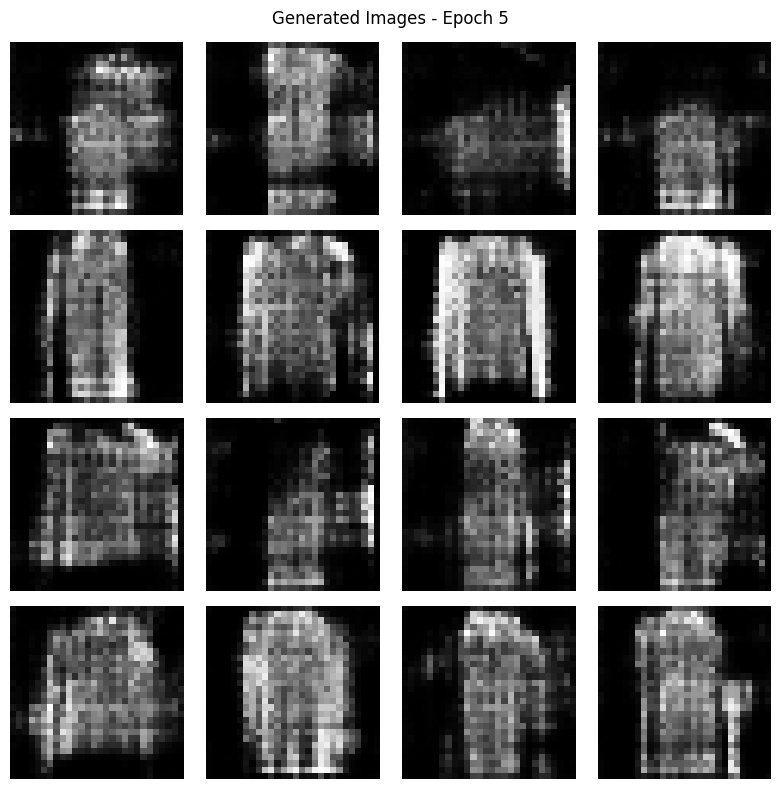

Epoch 06/30 | Generator Loss: 0.7696 | Discriminator Loss: 1.2966 | Time: 23.75s
Epoch 07/30 | Generator Loss: 0.7671 | Discriminator Loss: 1.3173 | Time: 23.07s
Epoch 08/30 | Generator Loss: 0.7943 | Discriminator Loss: 1.3096 | Time: 22.91s
Epoch 09/30 | Generator Loss: 0.7470 | Discriminator Loss: 1.3502 | Time: 23.23s
Epoch 10/30 | Generator Loss: 0.7476 | Discriminator Loss: 1.3575 | Time: 23.73s


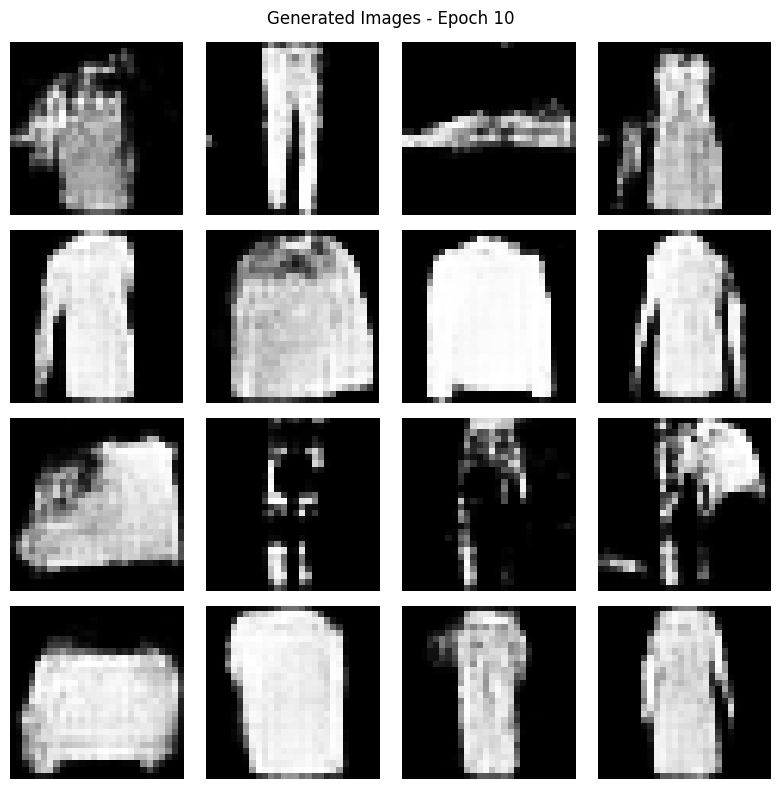

Epoch 11/30 | Generator Loss: 0.7502 | Discriminator Loss: 1.3493 | Time: 23.63s
Epoch 12/30 | Generator Loss: 0.7474 | Discriminator Loss: 1.3524 | Time: 23.17s
Epoch 13/30 | Generator Loss: 0.7310 | Discriminator Loss: 1.3571 | Time: 23.30s
Epoch 14/30 | Generator Loss: 0.7355 | Discriminator Loss: 1.3568 | Time: 23.49s
Epoch 15/30 | Generator Loss: 0.7431 | Discriminator Loss: 1.3567 | Time: 23.27s


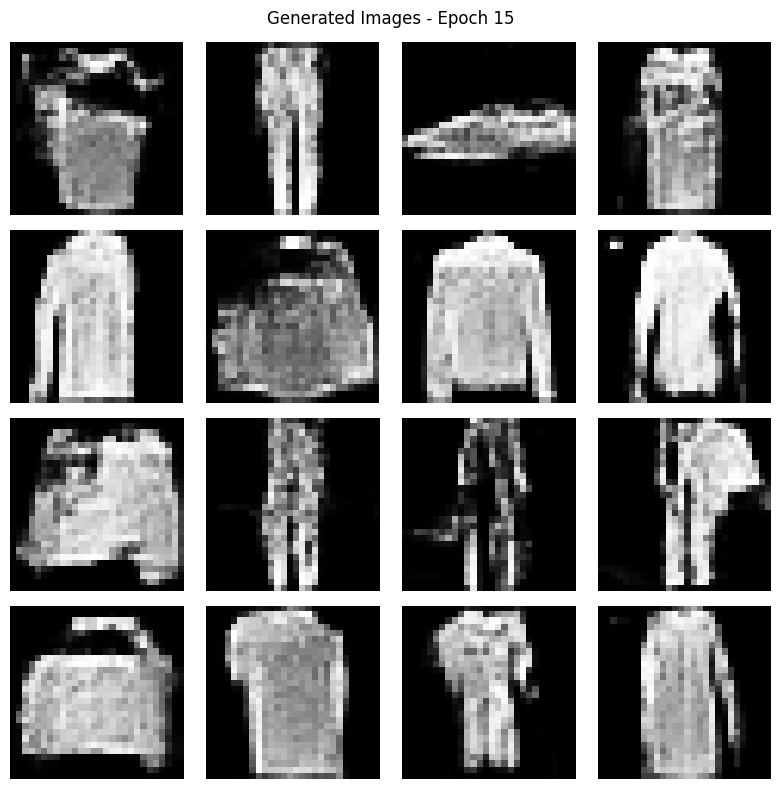

Epoch 16/30 | Generator Loss: 0.7241 | Discriminator Loss: 1.3623 | Time: 23.38s
Epoch 17/30 | Generator Loss: 0.7451 | Discriminator Loss: 1.3559 | Time: 23.77s
Epoch 18/30 | Generator Loss: 0.7359 | Discriminator Loss: 1.3551 | Time: 23.54s
Epoch 19/30 | Generator Loss: 0.7238 | Discriminator Loss: 1.3615 | Time: 22.92s
Epoch 20/30 | Generator Loss: 0.7382 | Discriminator Loss: 1.3585 | Time: 23.30s


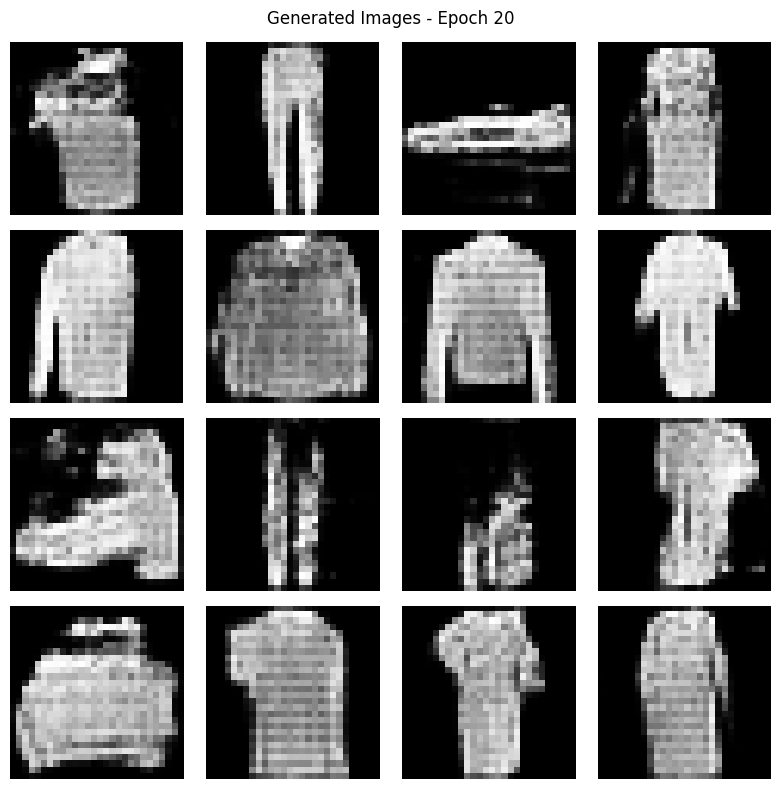

Epoch 21/30 | Generator Loss: 0.7502 | Discriminator Loss: 1.3504 | Time: 23.74s
Epoch 22/30 | Generator Loss: 0.7253 | Discriminator Loss: 1.3596 | Time: 23.26s
Epoch 23/30 | Generator Loss: 0.7250 | Discriminator Loss: 1.3625 | Time: 23.20s
Epoch 24/30 | Generator Loss: 0.7512 | Discriminator Loss: 1.3513 | Time: 23.69s
Epoch 25/30 | Generator Loss: 0.7409 | Discriminator Loss: 1.3537 | Time: 23.67s


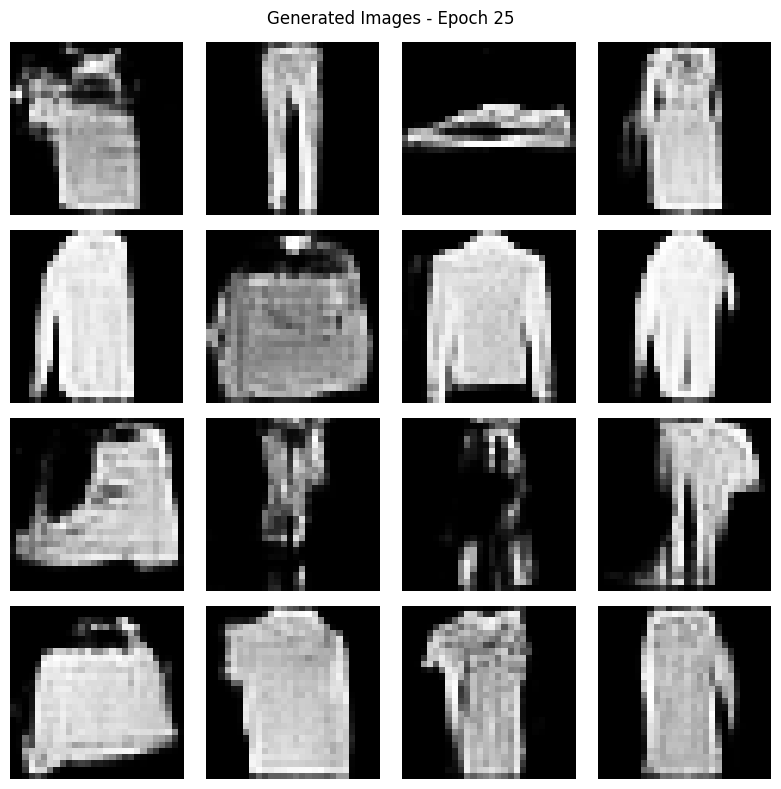

Epoch 26/30 | Generator Loss: 0.7260 | Discriminator Loss: 1.3613 | Time: 23.48s
Epoch 27/30 | Generator Loss: 0.7353 | Discriminator Loss: 1.3612 | Time: 23.51s
Epoch 28/30 | Generator Loss: 0.7413 | Discriminator Loss: 1.3565 | Time: 23.43s
Epoch 29/30 | Generator Loss: 0.7297 | Discriminator Loss: 1.3605 | Time: 23.46s
Epoch 30/30 | Generator Loss: 0.7354 | Discriminator Loss: 1.3587 | Time: 23.50s


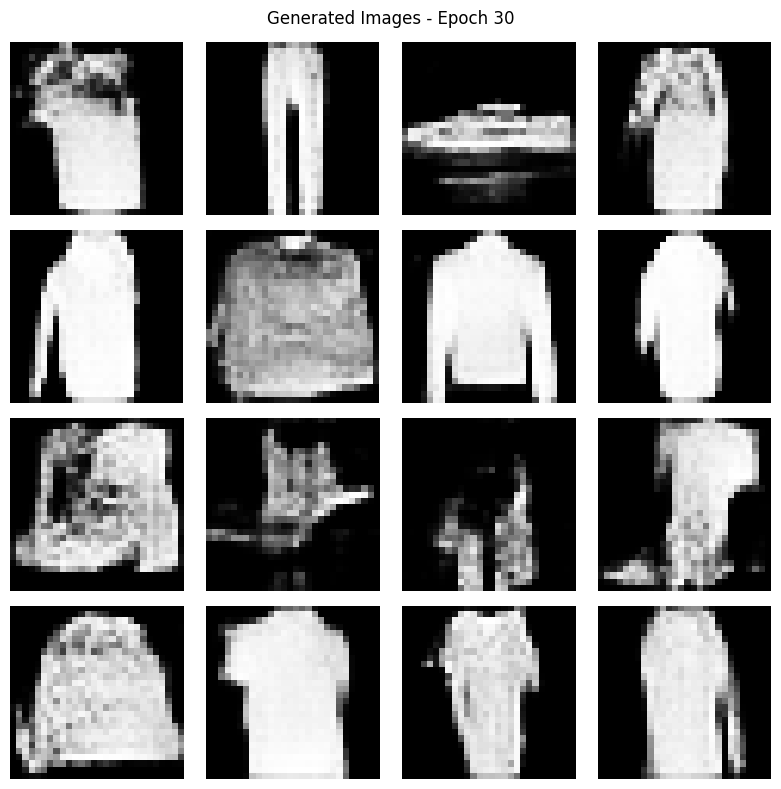

In [23]:
generator_losses = []
discriminator_losses = []
epoch_numbers = []

print("Starting DCGAN training...\n")

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    gen_loss_list = []
    disc_loss_list = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        gen_loss_list.append(
            gen_loss.numpy()
        )

        disc_loss_list.append(
            disc_loss.numpy()
        )

    avg_gen_loss = np.mean(
        gen_loss_list
    )

    avg_disc_loss = np.mean(
        disc_loss_list
    )

    generator_losses.append(
        avg_gen_loss
    )

    discriminator_losses.append(
        avg_disc_loss
    )

    epoch_numbers.append(epoch)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f} | "
        f"Time: {time.time() - start:.2f}s"
    )

    if epoch % 5 == 0:

        generate_and_save_images(
            generator,
            epoch
        )

# **26. Initial Observation of Training**

####The DCGAN training output displays the Generator loss and Discriminator loss for each epoch.

####During the first few epochs, the Generator is still learning the basic structure of the Fashion-MNIST images. Therefore, the generated images may appear noisy or contain unclear patterns.

####As the number of epochs increases, the Generator receives feedback from the Discriminator and adjusts its weights.

####The generated images can gradually develop patterns resembling clothing items.

####At the same time, the Discriminator also improves its ability to distinguish real images from generated images.

####The losses may fluctuate during training. This is expected because GAN training is a competitive process rather than a simple one-directional optimization problem.

####The exact loss values and visual quality of the images depend on the training process and random initialization.

# **27. Generator and Discriminator Loss Graph**

####The Generator and Discriminator losses recorded during training are plotted against the number of epochs.

####The loss graph is useful for understanding the behavior of the two networks during the training process.

####In a GAN, the losses do not necessarily decrease smoothly like the loss of a traditional classification or regression model.

####The Generator and Discriminator are competing against each other.

####When the Discriminator becomes better at identifying fake images, the Generator may experience a higher loss.

####When the Generator becomes better at creating realistic images, the Discriminator may find it more difficult to identify the fake images.

####Therefore, fluctuations in the loss curves are common in GAN training.

####The loss graph is studied together with the generated images because the loss values alone cannot completely describe the visual quality of a GAN.

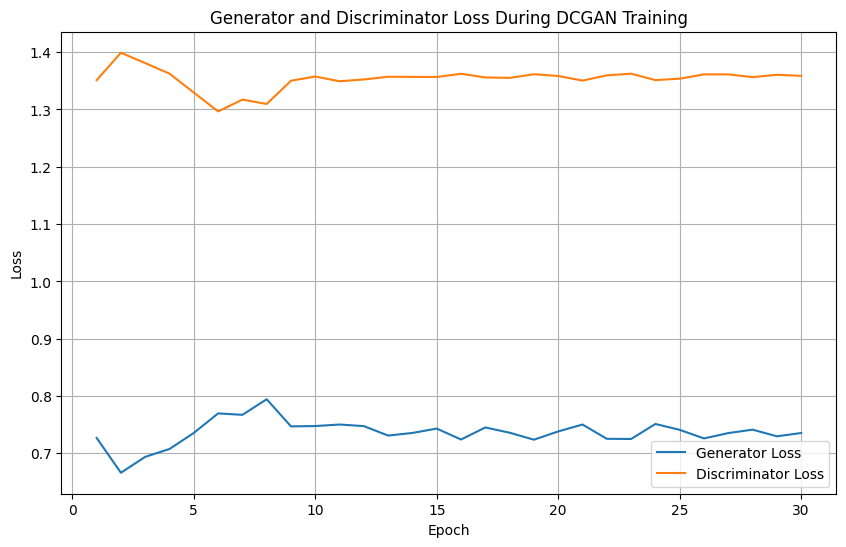

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    epoch_numbers,
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    epoch_numbers,
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Generator and Discriminator Loss During DCGAN Training"
)

plt.legend()
plt.grid(True)

plt.show()

# **28. Final Generated Images**

####After completing 30 epochs of training, the Generator is used to produce a final set of images.

####The same fixed noise vectors are used so that the final images can be compared with the images produced at earlier epochs.

####The generated images are expected to contain more structured patterns than the images produced before training.

####Some images may resemble specific Fashion-MNIST categories, such as footwear, shirts, trousers, bags or other clothing objects.

####However, the Generator is not directly told which class to generate because this is an unconditional DCGAN.

####Therefore, the model learns the overall distribution of Fashion-MNIST images rather than generating a specific class on demand.

####The quality of the final images depends on the training process and may vary between different runs.

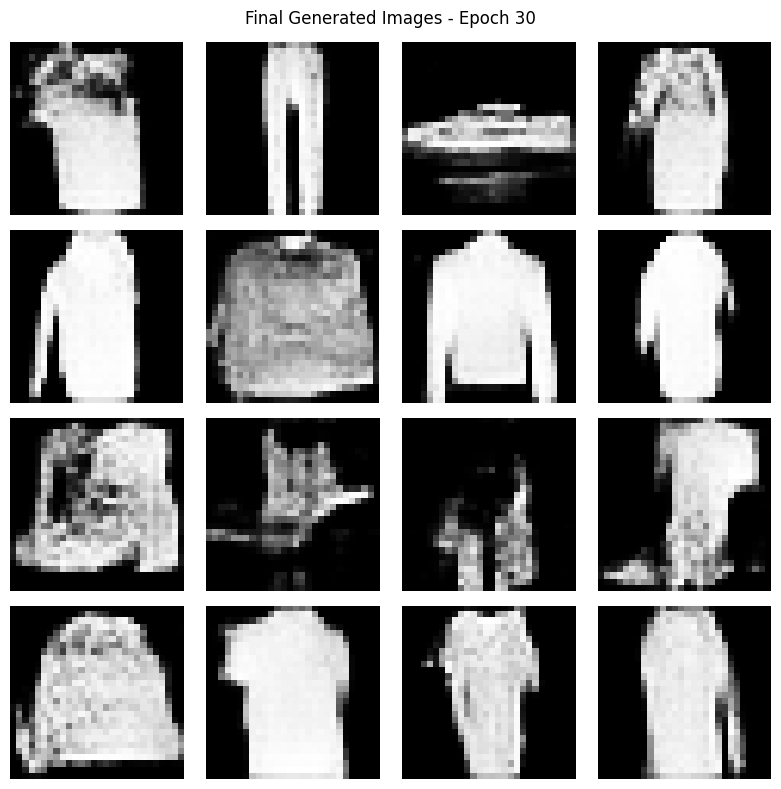

In [25]:
final_images = generator(
    seed,
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        (final_images[i, :, :, 0] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Generated Images - Epoch 30"
)

plt.tight_layout()
plt.show()

# **29. Comparison of Generated Images Across Epochs**

####The generated images from different training epochs are compared to understand how the Generator changes over time.

####The selected epochs are:

- Epoch 5
- Epoch 10
- Epoch 15
- Epoch 20
- Epoch 25
- Epoch 30

####At the beginning of training, the generated images are usually noisy and contain very few recognizable structures.

####As training progresses, the Generator learns more useful patterns from the Fashion-MNIST dataset.

####The later generated images can contain more organized shapes and structures that resemble fashion objects.

####This comparison provides a visual representation of the learning process.

####It is important to remember that GAN training can be unstable. Therefore, image quality may not improve perfectly at every single epoch.

####The overall objective is to observe whether the generated images become more structured and recognizable as training progresses.

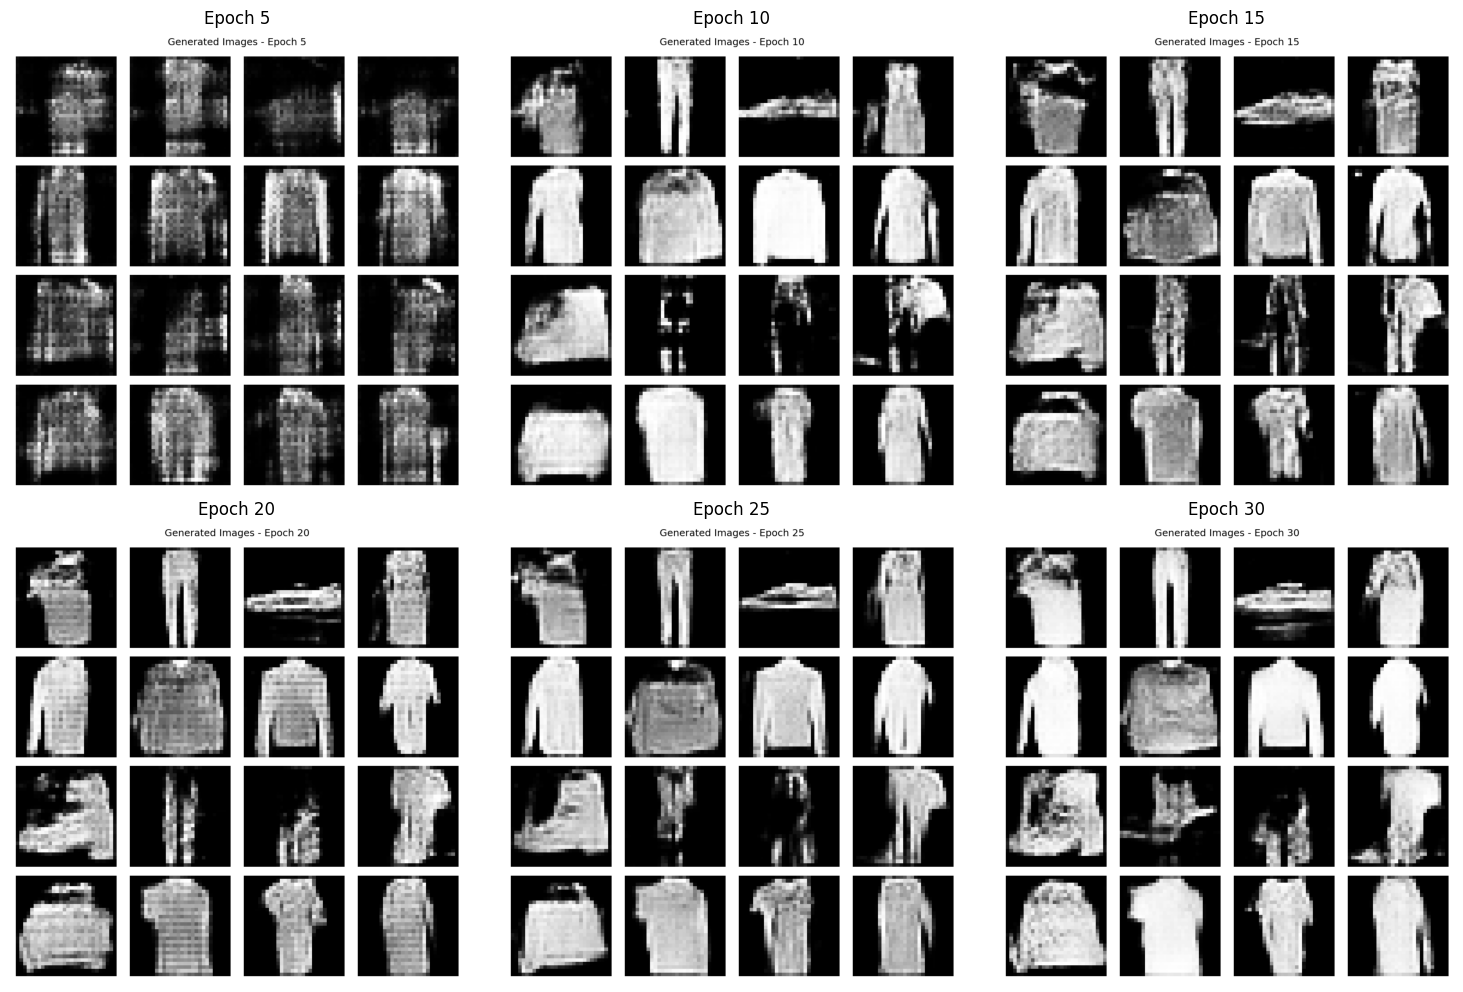

In [26]:
import matplotlib.image as mpimg

epochs_to_compare = [5, 10, 15, 20, 25, 30]

plt.figure(figsize=(15, 10))

for index, epoch in enumerate(epochs_to_compare):

    image = mpimg.imread(
        f"generated_epoch_{epoch}.png"
    )

    plt.subplot(2, 3, index + 1)

    plt.imshow(image)
    plt.title(f"Epoch {epoch}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **30. Analysis of the Training Process**

## ***30.1 How the Generated Images Look During Early Epochs***

During the early stages of training, the generated images generally appear unclear and noisy.

This happens because the Generator starts with randomly initialized weights and has not yet learned the visual characteristics of the Fashion-MNIST dataset.

The Generator receives random noise as input and initially produces random patterns.

At this stage, it is difficult to identify specific clothing categories from the generated images.

The Discriminator also begins with randomly initialized weights. As training progresses, it learns to recognize the difference between actual Fashion-MNIST images and the random images produced by the Generator.

Therefore, the early epochs represent the starting stage of the learning process.

# ***30.2 How the Images Improve as Training Continues***

As the number of training epochs increases, the Generator receives more feedback from the Discriminator.

This feedback helps the Generator adjust its internal weights.

The Generator gradually learns important visual patterns from the Fashion-MNIST dataset.

Instead of producing completely random patterns, it begins to create shapes and structures that resemble clothing items.

Edges, outlines and general object structures may become more visible.

The improvement is usually easier to observe by comparing the 4 × 4 grids from Epoch 5, Epoch 10, Epoch 15, Epoch 20, Epoch 25 and Epoch 30.

The later images should generally contain more recognizable patterns than the early images, although the improvement may not be perfectly smooth.

# ***30.3 When Recognizable Clothing Shapes Start Appearing***

The point at which recognizable clothing shapes appear depends on the training process.

During the earliest epochs, the generated images are mostly random and unclear.

After several epochs, the Generator begins to learn basic shapes and structures.

During the middle and later stages of training, some images may begin to resemble footwear, shirts, trousers, bags or other fashion-related objects.

The exact epoch should be identified by visually examining the generated image grids produced during the experiment.

For example, if the shapes become clearly visible around Epoch 10, this can be mentioned in the final observation.

The important point is that recognizable structures generally become more visible as the Generator learns from the training data.

# ***30.4 Whether Image Quality Improves***

The image quality generally improves as training progresses.

During the early epochs, the generated images contain a high amount of noise and have poorly defined structures.

During the middle stages, the Generator starts producing more meaningful shapes.

During the later stages, the generated images can become more organized and visually similar to the Fashion-MNIST dataset.

However, image quality does not necessarily improve continuously after every epoch.

GANs can experience fluctuations because the Generator and Discriminator are simultaneously learning and competing with each other.

Therefore, one epoch may produce better-looking images than another epoch even though the overall training process is improving.

The generated image grids should be considered along with the loss graph when evaluating the training process.

# ***30.5 Whether Mode Collapse or Instability Occurs***

GAN training can sometimes become unstable because two neural networks are being optimized at the same time.

The Generator attempts to fool the Discriminator, while the Discriminator attempts to correctly identify fake images.

If the Discriminator becomes too strong, the Generator may have difficulty learning from its feedback.

If the Generator becomes too strong, the Discriminator may struggle to distinguish real and fake images.

This competition can cause fluctuations in the Generator and Discriminator losses.

Another possible issue is mode collapse.

Mode collapse occurs when the Generator produces very similar images repeatedly instead of generating diverse samples.

To identify possible mode collapse in this experiment, the generated image grids should be visually inspected.

If most generated images look very similar, it may indicate reduced diversity.

If the generated images contain different shapes and patterns, the Generator is showing better diversity.

The loss curves should also be examined for unusual or large fluctuations.

# **31. Questions and Answers**

## ***Question 1: How do the generated images change from early epochs to later epochs?***

### **Answer:**

During the early epochs, the generated images are generally unclear and contain random patterns because the Generator has not learned the visual structure of the Fashion-MNIST dataset.

As training continues, the Generator receives feedback from the Discriminator and updates its weights.

The generated images gradually become more structured. Edges, outlines and clothing-like patterns begin to appear.

By the later epochs, some generated images become more recognizable and resemble fashion objects such as shoes, shirts, trousers and bags.

Therefore, the comparison between the early and later epochs shows that the Generator gradually learns to produce images that are more similar to the training dataset.

# ***Question 2: Can you observe instability in training?***

### **Answer:**

Yes, some degree of instability can be observed during DCGAN training.

Unlike a normal classification model, the Generator and Discriminator are trained simultaneously and have competing objectives.

The Generator tries to make fake images look real, while the Discriminator tries to identify those images as fake.

Because both networks are continuously improving, their losses may increase and decrease during different epochs.

The loss graph may therefore contain fluctuations instead of smooth curves.

Small fluctuations are normal during GAN training.

Large fluctuations or sudden changes may indicate stronger instability.

The generated images should also be examined because the loss values alone cannot completely describe GAN performance.

# ***Question 3: At which epoch do recognizable clothing shapes start appearing?***

### **Answer:**

Recognizable clothing-like shapes begin to appear after several epochs of training.

The exact epoch depends on the random initialization, training behavior and model performance.

The generated image grids from Epoch 5, Epoch 10, Epoch 15, Epoch 20, Epoch 25 and Epoch 30 should be visually compared.

The first epoch at which clear clothing-like structures become visible should be mentioned in the final observation.

For example, if the generated images become recognizable around Epoch 10, the observation can be written as:

"Recognizable clothing-like shapes start appearing around Epoch 10. The structures become clearer and more organized in the later epochs."

The actual observation should be based on the images generated by the Colab notebook.

# ***Question 4: Does the image quality continue improving throughout the training?***

### **Answer:**

The image quality generally improves as training progresses, especially during the early and middle stages.

However, the improvement is not always continuous.

GAN training is a competitive process, so the Generator and Discriminator can influence each other's performance.

Sometimes the Generator may produce better images in one epoch and slightly less clear images in another epoch.

This does not necessarily mean that the model has failed.

The overall trend should be evaluated by comparing the generated image grids and the loss graph.

If the later epochs generally contain more recognizable and structured images than the early epochs, the Generator can be considered to have improved during training.

# **32. Detailed Training Observation**

The training process demonstrates the competitive relationship between the Generator and Discriminator.

At the beginning of training, the Generator does not have enough knowledge about the Fashion-MNIST dataset. Its generated images therefore contain random patterns and noise.

The Discriminator initially learns to distinguish these poor-quality generated images from the real images relatively easily.

As the number of epochs increases, the Generator starts learning from the feedback provided through the Discriminator. It gradually learns common visual characteristics of the training dataset.

The generated images begin to show more meaningful structures. Some images may start resembling shoes, shirts, trousers, bags or other clothing categories.

At the same time, the Discriminator continues improving. It learns more detailed features that help it distinguish between real and generated images.

This creates a continuous competition between the two networks.

The loss curves may fluctuate because the networks do not have the same objective. The Generator attempts to minimize its ability to be detected, while the Discriminator attempts to maximize its ability to distinguish real and fake images.

The generated image grids provide a more direct visual representation of the Generator's progress.

By comparing images at different epochs, it is possible to observe whether the generated images become more structured, recognizable and diverse.

The training process also demonstrates that GANs can be difficult to train because good performance depends on maintaining a balance between the Generator and Discriminator.

# **33. Saving the Trained Models**

After training is completed, the Generator and Discriminator can be saved.

Saving the models allows them to be loaded and used later without repeating the complete training process.

The Generator can be used later to generate new Fashion-MNIST-like images from random noise.

The Discriminator can also be saved for future analysis or experimentation.

Saving the trained models is useful for maintaining the results of the experiment.

In [27]:
generator.save(
    "fashion_mnist_dcgan_generator.keras"
)

discriminator.save(
    "fashion_mnist_dcgan_discriminator.keras"
)

print("Generator and Discriminator saved successfully.")

Generator and Discriminator saved successfully.


# **34. Conclusion**

In this assignment, a Deep Convolutional Generative Adversarial Network (DCGAN) was successfully implemented using the Fashion-MNIST dataset.

The experiment involved two neural networks: a Generator and a Discriminator.

The Generator was designed using Dense and transposed convolutional layers. It received a random noise vector as input and gradually transformed the noise into a 28 × 28 grayscale image.

The Discriminator was designed using convolutional layers. It received both real Fashion-MNIST images and generated images and learned to distinguish between them.

The Fashion-MNIST images were normalized from the original pixel range of 0–255 to the range of -1 to +1. This normalization was compatible with the tanh activation function used in the final layer of the Generator.

Binary Cross Entropy was used as the loss function, while the Adam optimizer was used to update the Generator and Discriminator weights.

The DCGAN was trained for 30 epochs. A 4 × 4 grid containing 16 generated images was saved every 5 epochs. This resulted in generated image grids for Epoch 5, Epoch 10, Epoch 15, Epoch 20, Epoch 25 and Epoch 30.

The generated images were compared across different stages of training. Initially, the images were mostly random and unclear. As training progressed, the Generator learned visual patterns from the Fashion-MNIST dataset and started producing more structured and recognizable clothing-like shapes.

The Generator and Discriminator losses were also recorded and plotted. The loss curves showed the competitive nature of GAN training, where fluctuations are expected because both networks are continuously learning against each other.

The experiment demonstrated that a DCGAN can learn the visual distribution of a dataset and generate new synthetic images from random noise.

Overall, this assignment provided practical knowledge about GAN architecture, image preprocessing, convolutional networks, transposed convolution, adversarial training, loss functions, optimization and visual evaluation of generated images.

# **38. Final Result**

The DCGAN was trained successfully on the Fashion-MNIST dataset for 30 epochs.

### **Results Obtained:**

- Fashion-MNIST dataset was successfully loaded.
- Images were normalized from 0–255 to -1 to +1.
- A Generator using transposed convolutional layers was implemented.
- A Discriminator using convolutional layers was implemented.
- Generator and Discriminator loss functions were implemented.
- Adam optimizers were used for training.
- The model was trained for 30 epochs.
- 4 × 4 grids of generated images were produced every 5 epochs.
- Generator loss was recorded for every epoch.
- Discriminator loss was recorded for every epoch.
- Both losses were plotted after training.
- Generated images were compared across different epochs.
- The training process and image quality were analyzed.

The final results demonstrate the basic working principle of a Deep Convolutional Generative Adversarial Network for image generation.